In [68]:
import pandas as pd
import regex as re
import joblib
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.metrics import specificity_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from sklearn.model_selection import GridSearchCV
from nltk import download
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
download("wordnet")
# WordNetLemmatizer: convierte palabras a su forma base (running -> run)
lemmatizer = WordNetLemmatizer()
download("stopwords")
# stopwords: palabras comunes en inglés a filtrar (the, a, an, etc.)
stop_words = stopwords.words("english")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jjime\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jjime\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [57]:
## Metricas de clasificacion
def metricas_clas(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy,train_recall,train_specificity,train_precision,train_f1],
                               [test_accuracy, test_recall, test_specificity, test_precision,test_f1],
                               [diff_accuracy, diff_recall, diff_specificity, diff_precision, diff_f1]],
                              columns = ['Accuracy', 'Recall', 'Specificity', 'Precision', 'F1'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

# **0. CONTEXTUALIZACIÓN Y CARGA DE DATOS**

Objetivo: 

Desarrollar un sistema que sea capaz de detectar automáticamente si una página web contiene spam o no basándonos en su URL.

Variables: 
- url: dirección url de la web 
- is_spam: etiqueta para representar si una web o dirección url es spam(True) o no (False)

In [34]:
df=pd.read_csv("https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv")

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2999 entries, 0 to 2998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   url      2999 non-null   object
 1   is_spam  2999 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 26.5+ KB


In [36]:
df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


# 1. PROCESAMIENTO DE DATOS

## 1.1. Limpieza de datos

In [37]:
# Filas duplicadas
fil_dup=df["url"].duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 630 filas duplicadas


In [38]:
#Eliminamos filas duplicadas
df.drop_duplicates(subset="url", keep="last", inplace=True)
print('Columnas duplicadas eliminadas correctamente')

Columnas duplicadas eliminadas correctamente


## 1.2. Creación variable objetivo

In [39]:
df['is_spam'].replace({True:1, False:0}, inplace=True)

C:\Users\jjime\AppData\Local\Temp\ipykernel_15688\1240401325.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['is_spam'].replace({True:1, False:0}, inplace=True)
C:\Users\jjime\AppData\Local\Temp\ipykernel_15688\1240401325.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['is_spam'].repla

In [40]:
print(f'Valores únicos de is_spam: {df["is_spam"].unique()}')
print(f"Total de spam: {len(df.loc[df.is_spam == 1])}")
print(f"Total no spam: {len(df.loc[df.is_spam == 0])}")

Valores únicos de is_spam: [0 1]
Total de spam: 244
Total no spam: 2125


## 1.3. Procesamiento de los links

In [41]:
def procesamiento_links(http):
    """Limpia URLs extrayendo solo palabras significativas"""
    
    # Reemplaza caracteres no alfanuméricos por espacios
    # Ejemplo: "spam-2024.com" -> "spam   com"
    texto = re.sub(r'[^a-z ]', " ", http)
    
    # Elimina palabras de una sola letra (artículos, preposiciones)
    # Ejemplo: " a " -> " "
    texto = re.sub(r'\s+[a-zA-Z]\s+', " ", texto)
    texto = re.sub(r'\^[a-zA-Z]\s+', " ", texto)

    # Convierte a minúsculas y limpia espacios múltiples
    # Ejemplo: "SPAM  Google" -> "spam google"
    texto = re.sub(r'\s+', " ", texto.lower())

    # Elimina etiquetas HTML codificadas (&lt;...&gt;)
    texto = re.sub("&lt;/?.*?&gt;", " &lt;&gt; ", texto)

    # Convierte el string en lista de palabras
    return texto.split()

In [42]:
data=df.copy()
data["url"] = data["url"].apply(procesamiento_links)
data.head()

,url,is_spam
3,"[https, briefingday, com, m, commentform]",0
5,"[https, www, brookings, edu, interactives, reo...",0
6,"[https, www, reuters, com, investigates, speci...",0
7,"[https, www, theatlantic, com, magazine, archi...",0
8,"[https, www, vox, com, john, bolton, book, exc...",0


In [44]:
def lematizar_texto(palabras, lematizador = lemmatizer):
    # Convierte cada palabra a su forma base (corriendo -> correr, mejor -> bueno)
    tokens = [lematizador.lemmatize(palabra) for palabra in palabras]
    
    # Elimina palabras comunes sin valor (el, la, es, son, etc.)
    tokens = [palabra for palabra in tokens if palabra not in stop_words]
    
    # Filtra palabras muy cortas (menos de 3 caracteres)
    tokens = [palabra for palabra in tokens if len(palabra) > 3]
    
    return tokens

# Aplica la función a todas las URLs y muestra el resultado
data["url"] = data["url"].apply(lematizar_texto)
data.head()

,url,is_spam
3,"[http, briefingday, commentform]",0
5,"[http, brookings, interactives, reopening, ame...",0
6,"[http, reuters, investigates, special, report,...",0
7,"[http, theatlantic, magazine, archive, superma...",0
8,"[http, john, bolton, book, excerpt, trump, ukr...",0


## 1.4. Representación

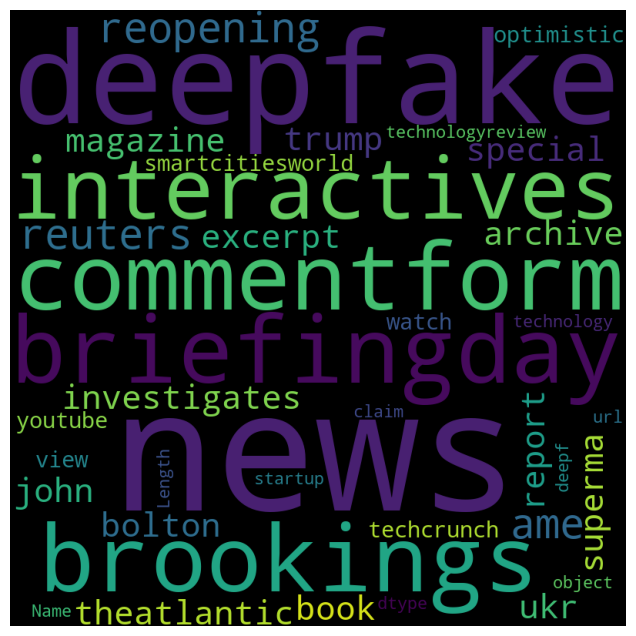

In [47]:
# Visualizamos las palabras más frecuentes en las URLs usando una nube de palabras

# Configuramos la nube de palabras con estos parámetros:
# - Tamaño: 800x800 píxeles para una buena visualización
# - Fondo negro para que resalten las palabras
# - Como máximo 1000 palabras diferentes
# - Tamaño mínimo de fuente para que se lean las menos frecuentes
wordcloud = WordCloud(width=800, height=800, background_color="black", max_words=1000, min_font_size=20, random_state=42)\
    .generate(str(data["url"]))

# Preparamos la figura donde mostraremos la nube
fig = plt.figure(figsize=(8, 8), facecolor=None)

# Mostramos la nube de palabras en la figura
plt.imshow(wordcloud)

# Quitamos los ejes para una visualización más limpia
plt.axis("off")

# Mostramos el gráfico en la celda
plt.show()

## 1.5. Vectorización y división del dataset

In [50]:
#Columnas con url preprocesadas
tokens_list = data["url"]

# Convertimos cada lista de palabras en un string unido por espacios: ["spam", "malware", "virus"] -> "spam malware virus"
tokens_list = [" ".join(tokens) for tokens in tokens_list]

# Creamos un vectorizador TF-IDF para convertir texto en números
# - max_features: usa las 5000 palabras más relevantes
# - max_df: ignora palabras que aparecen en más del 80% de documentos (muy comunes)
# - min_df: ignora palabras que aparecen en menos de 5 documentos (muy raras)
vectorizer = TfidfVectorizer(max_features=5000, max_df=0.8, min_df=5)

# Transformamos los textos en una matriz numérica donde cada fila es una URL y cada columna es una palabra, con valores TF-IDF
X = vectorizer.fit_transform(tokens_list).toarray()

# Extraemos la variable objetivo (si es spam o no)
y = data["is_spam"]

# Mostramos las primeras 5 filas de características
X[:5]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5, 538))

In [52]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# 2. ENTRENAMIENTO 

In [59]:
# Parámetros del modelo SVC:
# - kernel: tipo de función para separar los datos
#   * "linear": línea recta (mejor para datos linealmente separables, rápido)
#   * "poly": polinómio (curvas suaves, más flexible)
#   * "rbf": función de base radial (muy flexible, para datos complejos)
#   * "sigmoid": similar a redes neuronales
# - C: parámetro de regularización (penalty)
#   * Valores bajos: modelo más simple, menos overfitting
#   * Valores altos: modelo más complejo, más overfitting (por defecto C=1.0)
# - gamma: controla la influencia de cada ejemplo de entrenamiento
#   * "scale": 1 / (n_features * X.var()) - valor por defecto
#   * "auto": 1 / n_features
model = SVC(kernel="linear", random_state=42)

# Entrenamos el modelo
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


# 3. EVALUACIÓN DEL MODELO

## 3.1. Matriz de confusión y métricas

------------------------------------------------------------
GONFIGURACIÓN INICIAL
------------------------------------------------------------
            Accuracy    Recall  Specificity  Precision        F1
Train       0.949340  0.546875     0.994715   0.921053  0.686275
Test        0.919831  0.423077     0.981043   0.733333  0.536585
Diferencia  0.029509  0.123798     0.013673   0.187719  0.149689


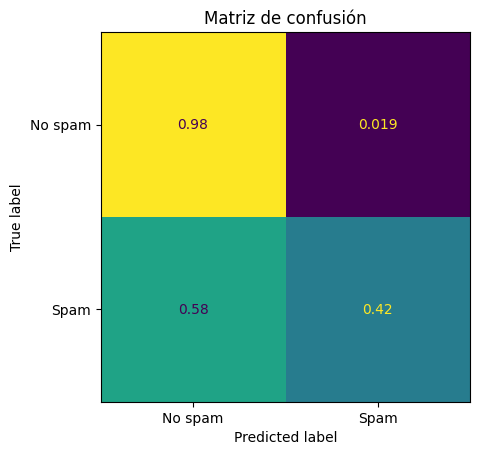

In [60]:
#Predicciones
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
## Métricas
print("-"*60)
print("GONFIGURACIÓN INICIAL")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))

##Matriz de confusión
cm = confusion_matrix(y_test, test_pred, labels=[0, 1], normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No spam", "Spam"])
disp.plot(cmap="viridis", colorbar=False)
plt.title("Matriz de confusión")
plt.show()


Podemos observar como el modelo tiene un mejor desempeño para predecir los correcos que nos son spam pues la base de datos está desbalanceada.

## 3.2. Optimización de hiperparámetros

In [64]:
import numpy as np
from sklearn.model_selection import GridSearchCV

# Definimos los hiperparámetros a optimizar
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "kernel": ["linear", "poly", "rbf", "sigmoid"],  # Sin "precomputed"
    "degree": [1, 2, 3, 4, 5],
    "gamma": ["scale", "auto"]
}

# Inicializamos GridSearchCV para encontrar la mejor combinación
grid = GridSearchCV(
    SVC(random_state=42), 
    hyperparams, 
    scoring="accuracy", 
    cv=5,
    verbose=2,
    n_jobs=-1  # Usa todos los núcleos del procesador
)

# Ejecutamos la búsqueda
grid_search = grid.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(grid_search.best_params_)
print(f"\nMejor accuracy: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 280 candidates, totalling 1400 fits


Mejores hiperparámetros:
{'C': 10, 'degree': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Mejor accuracy: 0.9414


In [65]:
#Comparación de métricas
##Predicciones
train_pred_opt = grid_search.predict(X_train)
test_pred_opt = grid_search.predict(X_test)
## Métricas
print("-"*60)
print("MODELO SIN OPTIMIZAR")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred, test_pred))
## Métricas
print("-"*60)
print("MODELO OPTIMIZADO")
print("-"*60)
print(metricas_clas(y_train, y_test, train_pred_opt, test_pred_opt))

------------------------------------------------------------
MODELO SIN OPTIMIZAR
------------------------------------------------------------
            Accuracy    Recall  Specificity  Precision        F1
Train       0.949340  0.546875     0.994715   0.921053  0.686275
Test        0.919831  0.423077     0.981043   0.733333  0.536585
Diferencia  0.029509  0.123798     0.013673   0.187719  0.149689
------------------------------------------------------------
MODELO OPTIMIZADO
------------------------------------------------------------
            Accuracy    Recall  Specificity  Precision        F1
Train       0.972032  0.760417     0.995890   0.954248  0.846377
Test        0.917722  0.538462     0.964455   0.651163  0.589474
Diferencia  0.054310  0.221955     0.031435   0.303086  0.256903


[]

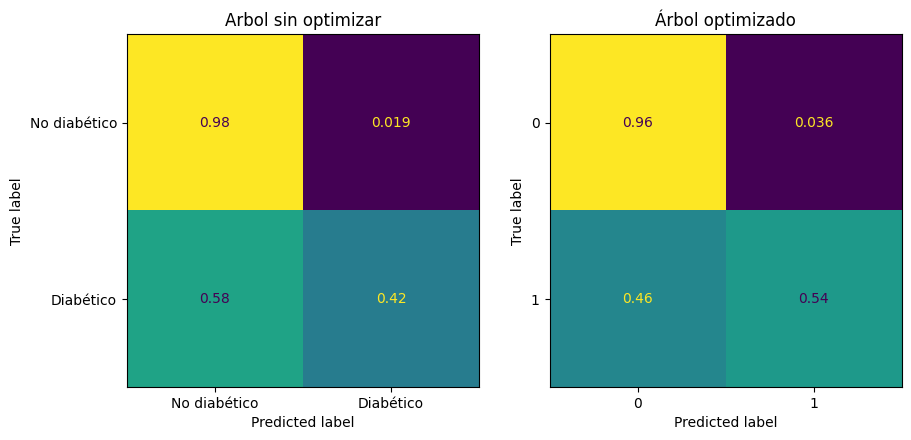

In [66]:
#Matriz de confusión
## Sin Optimizar
cm1 = confusion_matrix(y_test, test_pred, normalize='true')
## Optimizado
cm2 = confusion_matrix(y_test, test_pred_opt, normalize='true')

# Representación
fig, axis=plt.subplots(1,2, figsize=(10,5))
ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=["No diabético", "Diabético"]).plot(ax=axis[0],cmap='viridis',colorbar=False)
axis[0].set_title("Arbol sin optimizar")
ConfusionMatrixDisplay(confusion_matrix=cm2).plot(ax=axis[1],cmap='viridis', colorbar=False)
axis[1].set_title("Árbol optimizado")
plt.plot()

En este caso, podemos ver que la optimización ha hecho que el recall del modelo se incremente en 11 puntos porcentuales.

## 3.3. Exportamos el modelo

In [69]:
#Exportamos el modelo con joblib (más rápido que pickle)
joblib.dump(grid_search, "12-SVM.joblib")

['12-SVM.joblib']